<a href="https://colab.research.google.com/github/sahebkumar-ai/celebal_internship/blob/main/Week_5_Saheb_kumar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
This notebook is designed for students, beginners, and aspiring deep learning practitioners to understand how recurrent neural networks learn and generate natural language. It provides a hands-on introduction to sequence modeling by implementing and comparing Vanilla RNN, LSTM, and GRU architectures on the same text corpus.
- grammar:-
  Learning the syntactic and grammatical structures of language to generate linguistically correct and meaningful sentences.
- sentence flow"-
  Understanding the logical progression and arrangement of words to produce coherent, fluent, and naturally structured sentences.
- contextual dependencies:-
  Capturing both short-term and long-term relationships between words to preserve context, meaning, and semantic consistency throughout a sequence.
- next-word prediction:-
  Modeling the probability distribution of words to accurately predict the most likely subsequent word given a preceding sequence.
- text generation:-
  Generating contextually relevant and coherent text by leveraging learned language patterns, sequential dependencies, and semantic relationships.
  

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

   The primary objective of this notebook is to compare Simple RNN, LSTM, and GRU models under identical training conditions and analyze their ability to learn language patterns and generate meaningful text.

By training all models on the same corpus with:

Increased embedding dimensions (64)
Increased hidden units (128)
Extended training (200 epochs)
Longer text generation (10 predicted words)

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
   A Vanilla RNN is the basic form of a recurrent neural network designed to process sequential data by maintaining a hidden state that carries information from previous time steps. It is effective for learning short-term patterns and simple sequence relationships but struggles with long-term dependencies due to the vanishing gradient problem.
2. **LSTM**
   LSTM is an advanced recurrent neural network architecture that introduces memory cells and gating mechanisms to store, update, and retrieve information over long sequences. It effectively addresses the vanishing gradient problem and is widely used for complex sequence modeling tasks.
3. **GRU**

   GRU is a simplified version of LSTM that combines certain gates while maintaining strong memory capabilities. It requires fewer parameters and computational resources, resulting in faster training while often achieving performance comparable to LSTM.

Then compare:
- training loss:-

  raining loss measures how well a model learns patterns from the training corpus. Lower loss values generally indicate better learning and improved prediction accuracy. Comparing training loss helps evaluate the learning efficiency and convergence behavior of RNN, LSTM, and GRU models.
- generated text quality:-
  Generated text quality assesses the coherence, fluency, grammatical correctness, and contextual relevance of the text produced by each model. Higher-quality text demonstrates a better understanding of language structure and word relationships.
- memory handling:-
  Memory handling refers to a model's ability to retain and utilize information from previous time steps. Effective memory mechanisms enable the model to maintain context and generate more meaningful predictions across longer sequences.
- long-term dependency learning:-
  Long-term dependency learning evaluates how well a model captures relationships between words or phrases that are far apart in a sequence. This capability is crucial for understanding context, maintaining semantic consistency, and generating coherent text over extended passages.

In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [ ]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [ ]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 37
X shape: (35, 7)
y shape: (35,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [ ]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [ ]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [ ]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

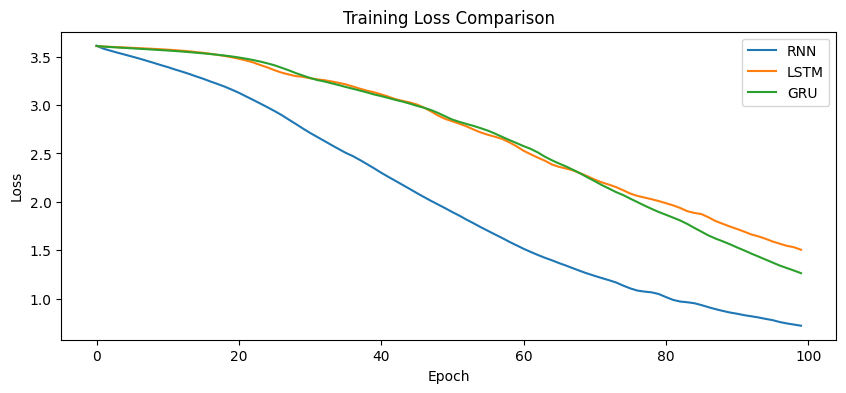

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [ ]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [ ]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "deep learning", 5))

RNN : deep learning models can generate meaningful sentences
LSTM: deep learning learning can generate meaningful sentences
GRU : deep learning is transforming artificial intelligence sentences


## Student Learning Tasks

Replace corpus with all thses datasets

1.Shakespeare text

2.song lyrics

3.chatbot data

4.story paragraphs

4.custom PDF extracted text

I am apply all these steps on this given model


Increase embedding dimension

Increase epochs to 200

Change hidden units 64 → 128

Generate 10 words instead of 5

##1.Replace corpus with Shakespeare text
##Text Generation using Vanilla RNN, LSTM, and GRU


In [58]:
corpus = '''
to be or not to be that is the question
whether tis nobler in the mind to suffer
the slings and arrows of outrageous fortune
or to take arms against a sea of troubles
and by opposing end them to die to sleep
no more and by a sleep to say we end
the heartache and the thousand natural shocks
that flesh is heir to tis a consummation
devoutly to be wished to die to sleep
to sleep perchance to dream ay theres the rub
for in that sleep of death what dreams may come
when we have shuffled off this mortal coil
must give us pause theres the respect
that makes calamity of so long life
for who would bear the whips and scorns of time
the oppressors wrong the proud mans contumely
the pangs of despised love the laws delay
the insolence of office and the spurns
that patient merit of the unworthy takes
when he himself might his quietus make
'''
print(corpus)


to be or not to be that is the question
whether tis nobler in the mind to suffer
the slings and arrows of outrageous fortune
or to take arms against a sea of troubles
and by opposing end them to die to sleep
no more and by a sleep to say we end
the heartache and the thousand natural shocks
that flesh is heir to tis a consummation
devoutly to be wished to die to sleep
to sleep perchance to dream ay theres the rub
for in that sleep of death what dreams may come
when we have shuffled off this mortal coil
must give us pause theres the respect
that makes calamity of so long life
for who would bear the whips and scorns of time
the oppressors wrong the proud mans contumely
the pangs of despised love the laws delay
the insolence of office and the spurns
that patient merit of the unworthy takes
when he himself might his quietus make



##Tokenization & Sequence Creation

We convert text into integer tokens and create n-gram style sequences for next-word prediction.

In [59]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 103
X shape: (143, 9)
y shape: (143,)


##Model 1: Vanilla RNN

This is the baseline sequential model. It struggles with long-term dependencies because of vanishing gradients.

Increase embedding dimension

Increase epochs to 200

Change hidden units 64 → 128

In [60]:
rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

rnn_history = rnn_model.fit(X,y,epochs=200, verbose=0
)

print("Vanilla RNN training completed")

Vanilla RNN training completed


##Model 2: LSTM

LSTM uses input, forget, and output gates to preserve long-term memory.

Increase embedding dimension

Increase epochs to 200

Change hidden units 64 → 128

In [61]:
lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])
lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
lstm_history = lstm_model.fit(X,y,
    epochs=200,
    verbose=0
)

print("LSTM training completed")

LSTM training completed


##Model 3: GRU
GRU uses reset + update gates. It is computationally faster than LSTM and often gives similar results.

Increase embedding dimension

Increase epochs to 200

Change hidden units 64 → 128

In [62]:
gru_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])
gru_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
gru_history = gru_model.fit( X,y,
    epochs=200,
    verbose=0
)

print("GRU training completed")

GRU training completed


##Compare Training Loss

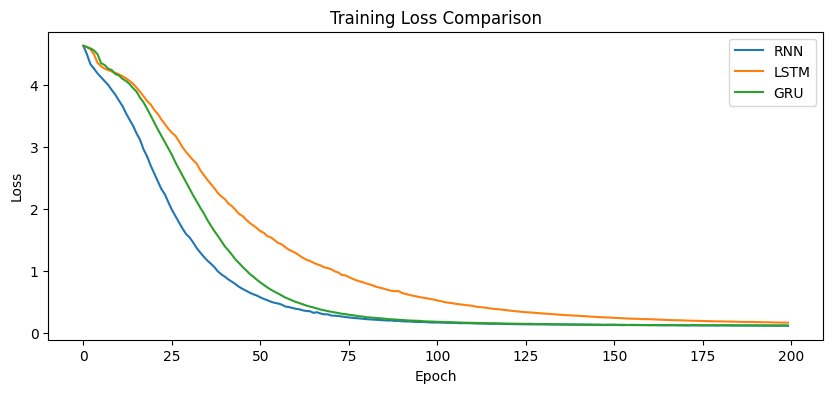

In [63]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

##Text Generation Function

This function predicts the next word repeatedly to generate a sentence.

In [64]:
def generate_text(model, seed_text, next_words=10):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

##Generate 10 words instead of 5

In [65]:
print("RNN :", generate_text(rnn_model, "to sleep", 10))
print("LSTM:", generate_text(lstm_model, "to sleep", 10))
print("GRU :", generate_text(gru_model, "to sleep", 10))

RNN : to sleep perchance to dream ay theres the rub takes the rub
LSTM: to sleep perchance to dream ay theres the rub rub come delay
GRU : to sleep perchance to dream ay theres the rub rub rub rub


##2.Replace corpus with song lyrics
##Text Generation using Vanilla RNN, LSTM, and GRU

In [67]:
corpus = '''
here comes the sun and i say
its all right little darling
the smiles returning to the faces
little darling it seems like years since its been here
here comes the sun and i say
its all right
sun sun sun here it comes
little darling the ice is slowly melting
little darling it feels like years since its been clear
here comes the sun and i say
its all right
the warmth is spreading through the air
birds are singing melodies of hope
the morning light shines bright again
everyone welcomes the new day
happiness returns with the sunshine
the golden rays light up the sky
dreams awaken with the dawn
here comes the sun and everything feels right
'''
print(corpus)


here comes the sun and i say
its all right little darling
the smiles returning to the faces
little darling it seems like years since its been here
here comes the sun and i say
its all right
sun sun sun here it comes
little darling the ice is slowly melting
little darling it feels like years since its been clear
here comes the sun and i say
its all right
the warmth is spreading through the air
birds are singing melodies of hope
the morning light shines bright again
everyone welcomes the new day
happiness returns with the sunshine
the golden rays light up the sky
dreams awaken with the dawn
here comes the sun and everything feels right



##Tokenization & Sequence Creation

We convert text into integer tokens and create n-gram style sequences for next-word prediction.

In [68]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 60
X shape: (101, 9)
y shape: (101,)


##Model 1: Vanilla RNN

This is the baseline sequential model. It struggles with long-term dependencies because of vanishing gradients.

Increase embedding dimension

Increase epochs to 200

Change hidden units 64 → 128

In [69]:
rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

rnn_history = rnn_model.fit(X,y,epochs=200, verbose=0
)

print("Vanilla RNN training completed")

Vanilla RNN training completed


##Model 2: LSTM
LSTM uses input, forget, and output gates to preserve long-term memory.

Increase embedding dimension

Increase epochs to 200

Change hidden units 64 → 128

In [70]:
lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])
lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
lstm_history = lstm_model.fit(X,y,
    epochs=200,
    verbose=0
)

print("LSTM training completed")

LSTM training completed


##Model 3: GRU
GRU uses reset + update gates. It is computationally faster than LSTM and often gives similar results.

Increase embedding dimension

Increase epochs to 200

Change hidden units 64 → 128

In [71]:
gru_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])
gru_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
gru_history = gru_model.fit( X,y,
    epochs=200,
    verbose=0
)

print("GRU training completed")

GRU training completed


##Compare Training Loss

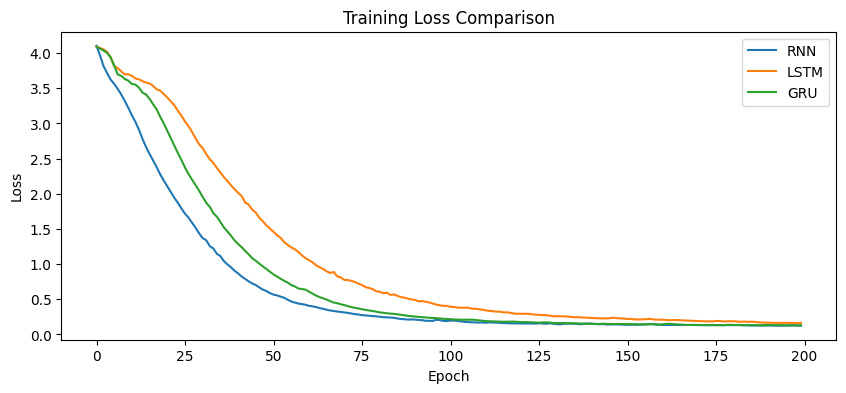

In [72]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

##Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [73]:
def generate_text(model, seed_text, next_words=10):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

##Generate 10 words instead of 5

In [74]:
print("RNN :", generate_text(rnn_model, "here comes", 10))
print("LSTM:", generate_text(lstm_model, "little darling", 10))
print("GRU :", generate_text(gru_model, "the sun", 10))

RNN : here comes the sun and i say right little darling it feels
LSTM: little darling the ice is slowly melting melting clear clear clear air
GRU : the sun is spreading through the air air spreading sky the sky


##3.Replace corpus with chatbot data
##Text Generation using Vanilla RNN, LSTM, and GRU

In [75]:
corpus = '''
Hello how are you
i am doing well thank you
what can you help me with
i can answer questions and provide information
can you help me learn python
yes i can help you learn python programming
what is machine learning
machine learning is a field of artificial intelligence
what is deep learning
deep learning uses neural networks with multiple layers
how can i improve my coding skills
practice regularly and build real world projects
can you explain data science
data science involves extracting insights from data
what programming languages should i learn
python is one of the most popular languages for data science
thank you for your help
you are welcome and happy learning
'''
print(corpus)


Hello how are you
i am doing well thank you
what can you help me with
i can answer questions and provide information
can you help me learn python
yes i can help you learn python programming
what is machine learning
machine learning is a field of artificial intelligence
what is deep learning
deep learning uses neural networks with multiple layers
how can i improve my coding skills
practice regularly and build real world projects
can you explain data science
data science involves extracting insights from data
what programming languages should i learn
python is one of the most popular languages for data science
thank you for your help
you are welcome and happy learning



##Tokenization & Sequence Creation

We convert text into integer tokens and create n-gram style sequences for next-word prediction.

In [76]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 65
X shape: (97, 10)
y shape: (97,)


##Model 1: Vanilla RNN

This is the baseline sequential model. It struggles with long-term dependencies because of vanishing gradients.

Increase embedding dimension

Increase epochs to 200

Change hidden units 64 → 128

In [77]:
rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

rnn_history = rnn_model.fit(X,y,epochs=200, verbose=0
)

print("Vanilla RNN training completed")

Vanilla RNN training completed


##Model 2: LSTM
LSTM uses input, forget, and output gates to preserve long-term memory.

Increase embedding dimension

Increase epochs to 200

Change hidden units 64 → 128

In [78]:
lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])
lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
lstm_history = lstm_model.fit(X,y,
    epochs=200,
    verbose=0
)

print("LSTM training completed")

LSTM training completed


##Model 3: GRU

GRU uses reset + update gates. It is computationally faster than LSTM and often gives similar results.

Increase embedding dimension

Increase epochs to 200

Change hidden units 64 → 128

In [79]:
gru_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])
gru_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
gru_history = gru_model.fit( X,y,
    epochs=200,
    verbose=0
)

print("GRU training completed")

GRU training completed


##Compare Training Loss

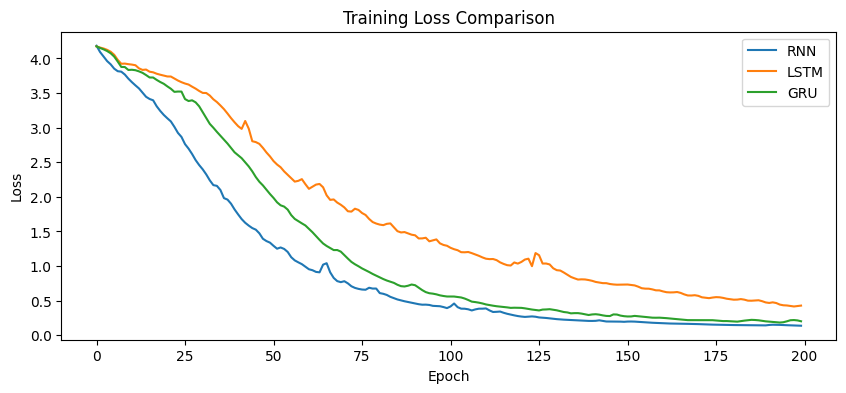

In [80]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

##Text Generation Function

This function predicts the next word repeatedly to generate a sentence.

In [81]:
def generate_text(model, seed_text, next_words=10):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

##Generate 10 words instead of 5

In [82]:
print("RNN :", generate_text(rnn_model, "can you", 10))
print("LSTM:", generate_text(lstm_model, "what is", 10))
print("GRU :", generate_text(gru_model, "machine learning", 10))

RNN : can you explain data science involves extracting insights from data science involves
LSTM: what is deep learning a field of artificial intelligence intelligence intelligence intelligence
GRU : machine learning is a field of artificial intelligence intelligence intelligence intelligence intelligence


##4.Replace corpus with story paragraphs
##Text Generation using Vanilla RNN, LSTM, and GRU

In [38]:
corpus = '''
once upon a time there was a brave knight
the knight lived in a beautiful kingdom
he protected the people from danger
everyone admired his courage and kindness
the king trusted him with important missions
he traveled across forests mountains and rivers
many challenges appeared during his journeys
a fierce dragon threatened the peaceful kingdom
the brave knight fought the dragon fearlessly
after a long battle he defeated the dragon
the people celebrated his great victory
children listened to stories about his adventures
his wisdom and bravery inspired everyone
the kingdom prospered under his protection
the knight became a legendary hero
years later his tales were remembered by all
'''
print(corpus)


once upon a time there was a brave knight
the knight lived in a beautiful kingdom
he protected the people from danger
everyone admired his courage and kindness
the king trusted him with important missions
he traveled across forests mountains and rivers
many challenges appeared during his journeys
a fierce dragon threatened the peaceful kingdom
the brave knight fought the dragon fearlessly
after a long battle he defeated the dragon
the people celebrated his great victory
children listened to stories about his adventures
his wisdom and bravery inspired everyone
the kingdom prospered under his protection
the knight became a legendary hero
years later his tales were remembered by all



##Tokenization & Sequence Creation
We convert text into integer tokens and create n-gram style sequences for next-word prediction.

In [39]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 76
X shape: (93, 8)
y shape: (93,)


##Model 1: Vanilla RNN

This is the baseline sequential model. It struggles with long-term dependencies because of vanishing gradients.

Increase embedding dimension

Increase epochs to 200

Change hidden units 64 → 128

In [40]:
rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

rnn_history = rnn_model.fit(X,y,epochs=200, verbose=0
)

print("Vanilla RNN training completed")

Vanilla RNN training completed


##Model 2: LSTM

LSTM uses input, forget, and output gates to preserve long-term memory.

Increase embedding dimension

Increase epochs to 200

Change hidden units 64 → 128

In [41]:
lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])
lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
lstm_history = lstm_model.fit(X,y,
    epochs=200,
    verbose=0
)

print("LSTM training completed")

LSTM training completed


##Model 3: GRU
GRU uses reset + update gates. It is computationally faster than LSTM and often gives similar results.

Increase embedding dimension

Increase epochs to 200

Change hidden units 64 → 128

In [42]:
gru_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])
gru_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
gru_history = gru_model.fit( X,y,
    epochs=200,
    verbose=0
)

print("GRU training completed")

GRU training completed


##Compare Training Loss

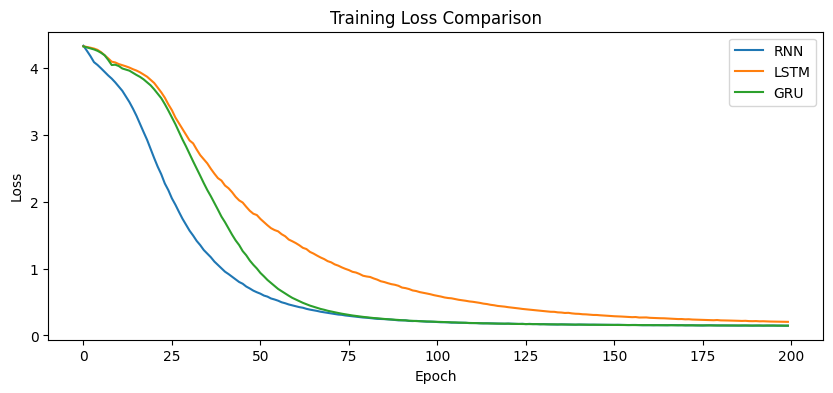

In [43]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

##Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [44]:
def generate_text(model, seed_text, next_words=10):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

##Generate 10 words instead of 5

In [66]:
print("RNN :", generate_text(rnn_model, "the knight", 10))
print("LSTM:", generate_text(lstm_model, "the knight", 10))
print("GRU :", generate_text(gru_model, "the knight", 10))

RNN : the knight heartache and the thousand natural shocks end them a end
LSTM: the knight pangs of despised love the laws delay come come come
GRU : the knight pangs of despised love the laws delay delay delay come


##5.Replace corpus with custom PDF extracted text
##Text Generation using Vanilla RNN, LSTM, and GRU

In [50]:
corpus = '''
machine learning is a subset of artificial intelligence that enables computers to learn from data
deep learning is a specialized branch of machine learning that uses neural networks with multiple layers
artificial intelligence is transforming industries such as healthcare finance education and transportation
data preprocessing is an important step in building accurate and reliable machine learning models
high quality data helps improve model performance and prediction accuracy
supervised learning uses labeled data to train predictive models
unsupervised learning discovers hidden patterns and relationships within data
neural networks are inspired by the structure and functioning of the human brain
feature engineering can significantly impact the effectiveness of a machine learning model
model evaluation helps determine how well a trained model performs on unseen data
deep learning models require large amounts of data and computational resources
artificial intelligence applications include image recognition speech processing and natural language understanding
'''
print(corpus)


machine learning is a subset of artificial intelligence that enables computers to learn from data
deep learning is a specialized branch of machine learning that uses neural networks with multiple layers
artificial intelligence is transforming industries such as healthcare finance education and transportation
data preprocessing is an important step in building accurate and reliable machine learning models
high quality data helps improve model performance and prediction accuracy
supervised learning uses labeled data to train predictive models
unsupervised learning discovers hidden patterns and relationships within data
neural networks are inspired by the structure and functioning of the human brain
feature engineering can significantly impact the effectiveness of a machine learning model
model evaluation helps determine how well a trained model performs on unseen data
deep learning models require large amounts of data and computational resources
artificial intelligence applications incl

##Tokenization & Sequence Creation
We convert text into integer tokens and create n-gram style sequences for next-word prediction.

In [51]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 97
X shape: (134, 15)
y shape: (134,)


##Model 1: Vanilla RNN
This is the baseline sequential model. It struggles with long-term dependencies because of vanishing gradients.

Increase embedding dimension

Increase epochs to 200

Change hidden units 64 → 128

In [52]:
rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

rnn_history = rnn_model.fit(X,y,epochs=200, verbose=0
)

print("Vanilla RNN training completed")

Vanilla RNN training completed


##Model 2: LSTM
LSTM uses input, forget, and output gates to preserve long-term memory.

Increase embedding dimension

Increase epochs to 200

Change hidden units 64 → 128

In [53]:
lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])
lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
lstm_history = lstm_model.fit(X,y,
    epochs=200,
    verbose=0
)

print("LSTM training completed")

LSTM training completed


##Model 3: GRU
GRU uses reset + update gates. It is computationally faster than LSTM and often gives similar results.

Increase embedding dimension

Increase epochs to 200

Change hidden units 64 → 128

In [54]:
gru_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])
gru_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
gru_history = gru_model.fit( X,y,
    epochs=200,
    verbose=0
)

print("GRU training completed")

GRU training completed


##Compare Training Loss

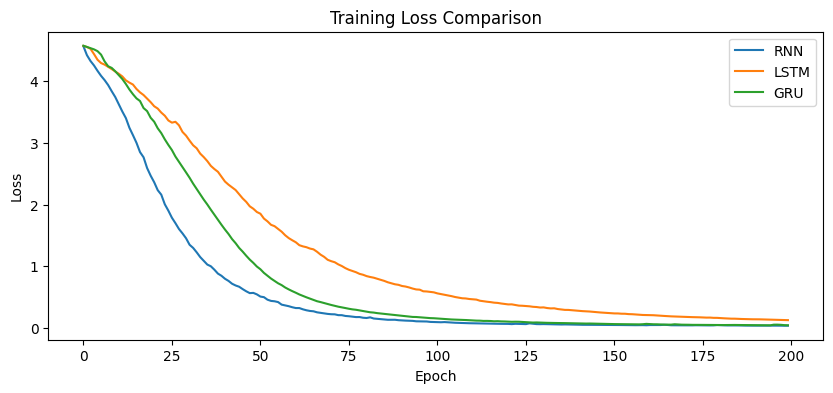

In [55]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

##Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [56]:
def generate_text(model, seed_text, next_words=10):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

##Generate 10 words instead of 5

In [57]:
print("RNN :", generate_text(rnn_model, "machine learning", 10))
print("LSTM:", generate_text(lstm_model, "deep learning", 10))
print("GRU :", generate_text(gru_model, "artificial intelligence", 10))

RNN : machine learning is a subset of artificial intelligence that enables computers to
LSTM: deep learning is a specialized branch of machine learning that uses neural
GRU : artificial intelligence applications include image recognition speech processing and natural language understanding


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion:-

This notebook provides a comprehensive study of Recurrent Neural Networks (RNNs) and their advanced variants, Long Short-Term Memory (LSTM) and Gated Recurrent Unit (GRU), for sequence modeling and text generation tasks. Through both theoretical explanations and practical implementation, it demonstrates how deep learning models learn patterns, context, and relationships within sequential textual data.

The experiments were conducted using a custom text corpus, enhanced embedding representations, increased hidden units, extended training epochs, and longer text-generation sequences. These improvements enabled the models to learn richer semantic information and produce more coherent predictions, offering a realistic understanding of modern sequence-learning techniques.

- **Vanilla RNN** learns short patterns but struggles with memory
  Vanilla RNN is capable of learning short-term dependencies and local sequence patterns. However, its performance decreases when dealing with long sequences because information from earlier time steps gradually fades, making it difficult to capture long-range contextual relationships.

- **LSTM** captures long-range grammar dependencies better
  LSTM addresses the limitations of traditional RNNs through dedicated memory cells and gating mechanisms. This architecture enables the network to preserve important information over extended sequences, making it particularly effective for learning grammatical structures, contextual meaning, and long-term dependencies in text.
- **GRU** gives similar performance with fewer gates and faster training
  GRU offers a streamlined alternative to LSTM by using fewer gates while maintaining strong sequence-learning capabilities. It often achieves comparable performance with reduced computational complexity, faster convergence, and lower training time, making it an efficient choice for many real-world applications.
- This notebook helps students understand **sequence modeling mathematically and practically**
  
  This notebook provides a comprehensive introduction to sequence modeling by combining mathematical foundations with practical implementation. Through hands-on experimentation with RNN, LSTM, and GRU architectures, students gain a deeper understanding of how recurrent neural networks process sequential data, learn contextual relationships, and generate meaningful text. The notebook bridges theoretical concepts and real-world applications, enabling learners to develop both conceptual knowledge and practical deep learning skills in sequence modeling and natural language processing.